In [1]:
!unzip -q "/content/PlantData.zip" -d /content/FastData

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# --- 1. CONFIGURATION ---
# Paste the path to your UNZIPPED folder here!
DATA_DIR = '/content/FastData/PlantData'

# Your model will still safely save to your Google Drive
MODEL_SAVE_PATH = '/content/drive/MyDrive/DenseNet/best_densenet.keras'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# --- 2. LOAD DATA ---
print(f"Loading images from: {DATA_DIR}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# --- Extract class names BEFORE prefetching ---
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# --- Optimize loading speed AFTER ---
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# --- 3. BUILD DENSENET MODEL ---
preprocess_input = applications.densenet.preprocess_input

base_model = applications.DenseNet121(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)

x = layers.RandomFlip("horizontal_and_vertical")(x)
x = layers.RandomRotation(0.2)(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 4. TRAIN MODEL ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

print("\n--- Starting Training ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print(f"\nTraining Complete! Best model saved to: {MODEL_SAVE_PATH}")

Loading images from: /content/FastData/PlantData
Found 11999 files belonging to 28 classes.
Using 8400 files for training.
Found 11999 files belonging to 28 classes.
Using 3599 files for validation.
Found 28 classes: ['AppleBlackRot', 'AppleCedarRust', 'AppleHealthy', 'AppleScab', 'BananaBlackSigatoka', 'BananaBractMosaicVirus', 'BananaHealthy', 'BananaInsectPest', 'BananaMoko', 'BananaPanama', 'BananaYellowSigatoka', 'CucumberAnthranose', 'CucumberBacterialWilt', 'CucumberDownyMildew', 'CucumberGummyStemBlight', 'CucumberHealthy', 'EggplantHealthy', 'EggplantInsectPest', 'EggplantLeafSpot', 'EggplantMosaicVirus', 'EggplantSmallLeaf', 'EggplantWhiteMold', 'EggplantWilt', 'PumpkinBacterialLeafSpot', 'PumpkinDownyMildew', 'PumpkinHealthy', 'PumpkinMosaic', 'PumpkinPowderyMildew']
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Starting Training ---
Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 104s 322ms/step - accuracy: 0.5861 - loss: 1.3018 - val_accuracy: 0.8213 - val_loss: 0.5302
E

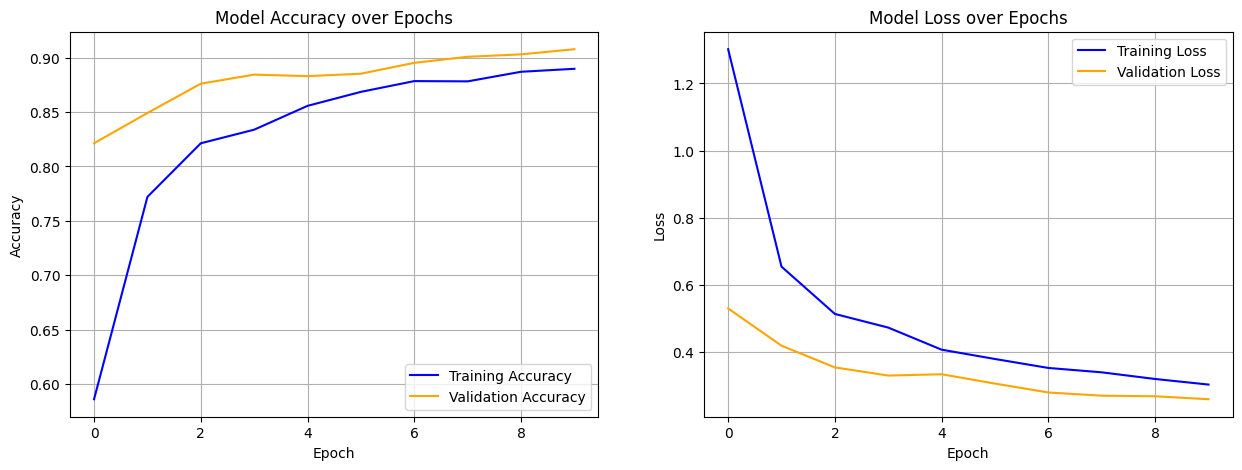

In [4]:
import matplotlib.pyplot as plt

# Create a figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot 2: Loss
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

In [5]:
print("\n--- Starting Phase 2: Fine-Tuning ---")

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Recompile with a VERY low learning rate (e.g., 1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Add a Learning Rate Scheduler (Lowers the LR automatically if it gets stuck)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,   # Drop learning rate to 20% of its current value...
    patience=2,   # ...if validation loss doesn't improve for 2 epochs
    min_lr=1e-7
)

# Update callbacks
callbacks_finetune = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    reduce_lr
]

# 4. Train again for another 10 epochs
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_finetune
)

print(f"\nFine-tuning Complete! Best model saved to: {MODEL_SAVE_PATH}")


--- Starting Phase 2: Fine-Tuning ---
Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 280s 789ms/step - accuracy: 0.6429 - loss: 1.4301 - val_accuracy: 0.8563 - val_loss: 0.4238 - learning_rate: 1.0000e-05
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 205s 778ms/step - accuracy: 0.8193 - loss: 0.5471 - val_accuracy: 0.8927 - val_loss: 0.3164 - learning_rate: 1.0000e-05
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 261s 775ms/step - accuracy: 0.8577 - loss: 0.4194 - val_accuracy: 0.9125 - val_loss: 0.2553 - learning_rate: 1.0000e-05
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 261s 772ms/step - accuracy: 0.8808 - loss: 0.3420 - val_accuracy: 0.9255 - val_loss: 0.2164 - learning_rate: 1.0000e-05
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 205s 779ms/step - accuracy: 0.8989 - loss: 0.2958 - val_accuracy: 0.9300 - val_loss: 0.2059 - learning_rate: 1.0000e-05
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 225s 855ms/step - accuracy: 0.9101 - loss: 0.2592 - val_accuracy: 0.9369 - val_loss: 0.1886 - learning_rate: 1.0000e-05
E

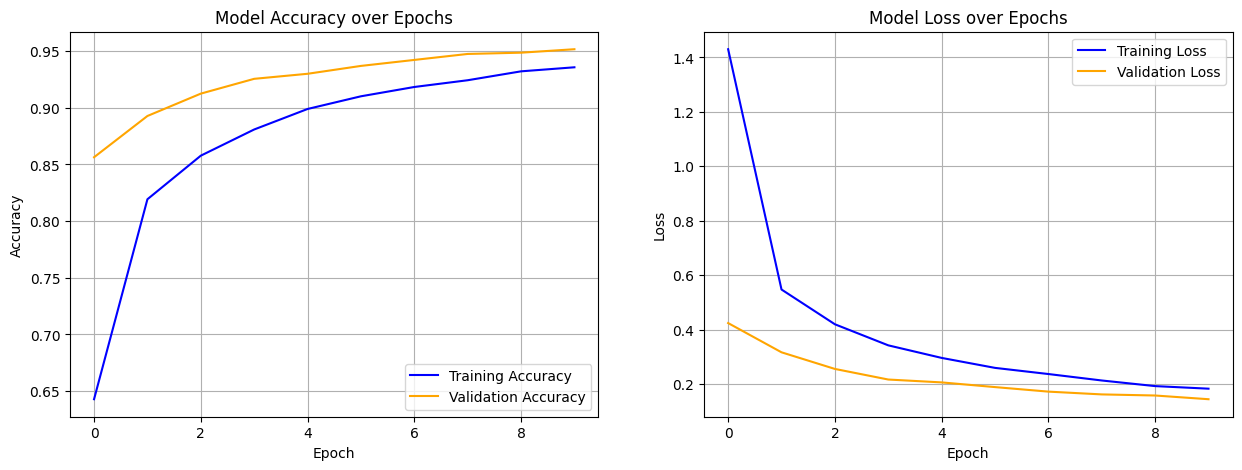

In [7]:
import matplotlib.pyplot as plt

# Create a figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy
ax1.plot(history_finetune.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot 2: Loss
ax2.plot(history_finetune.history['loss'], label='Training Loss', color='blue')
ax2.plot(history_finetune.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

Generating predictions on the validation set... (this takes a few seconds)


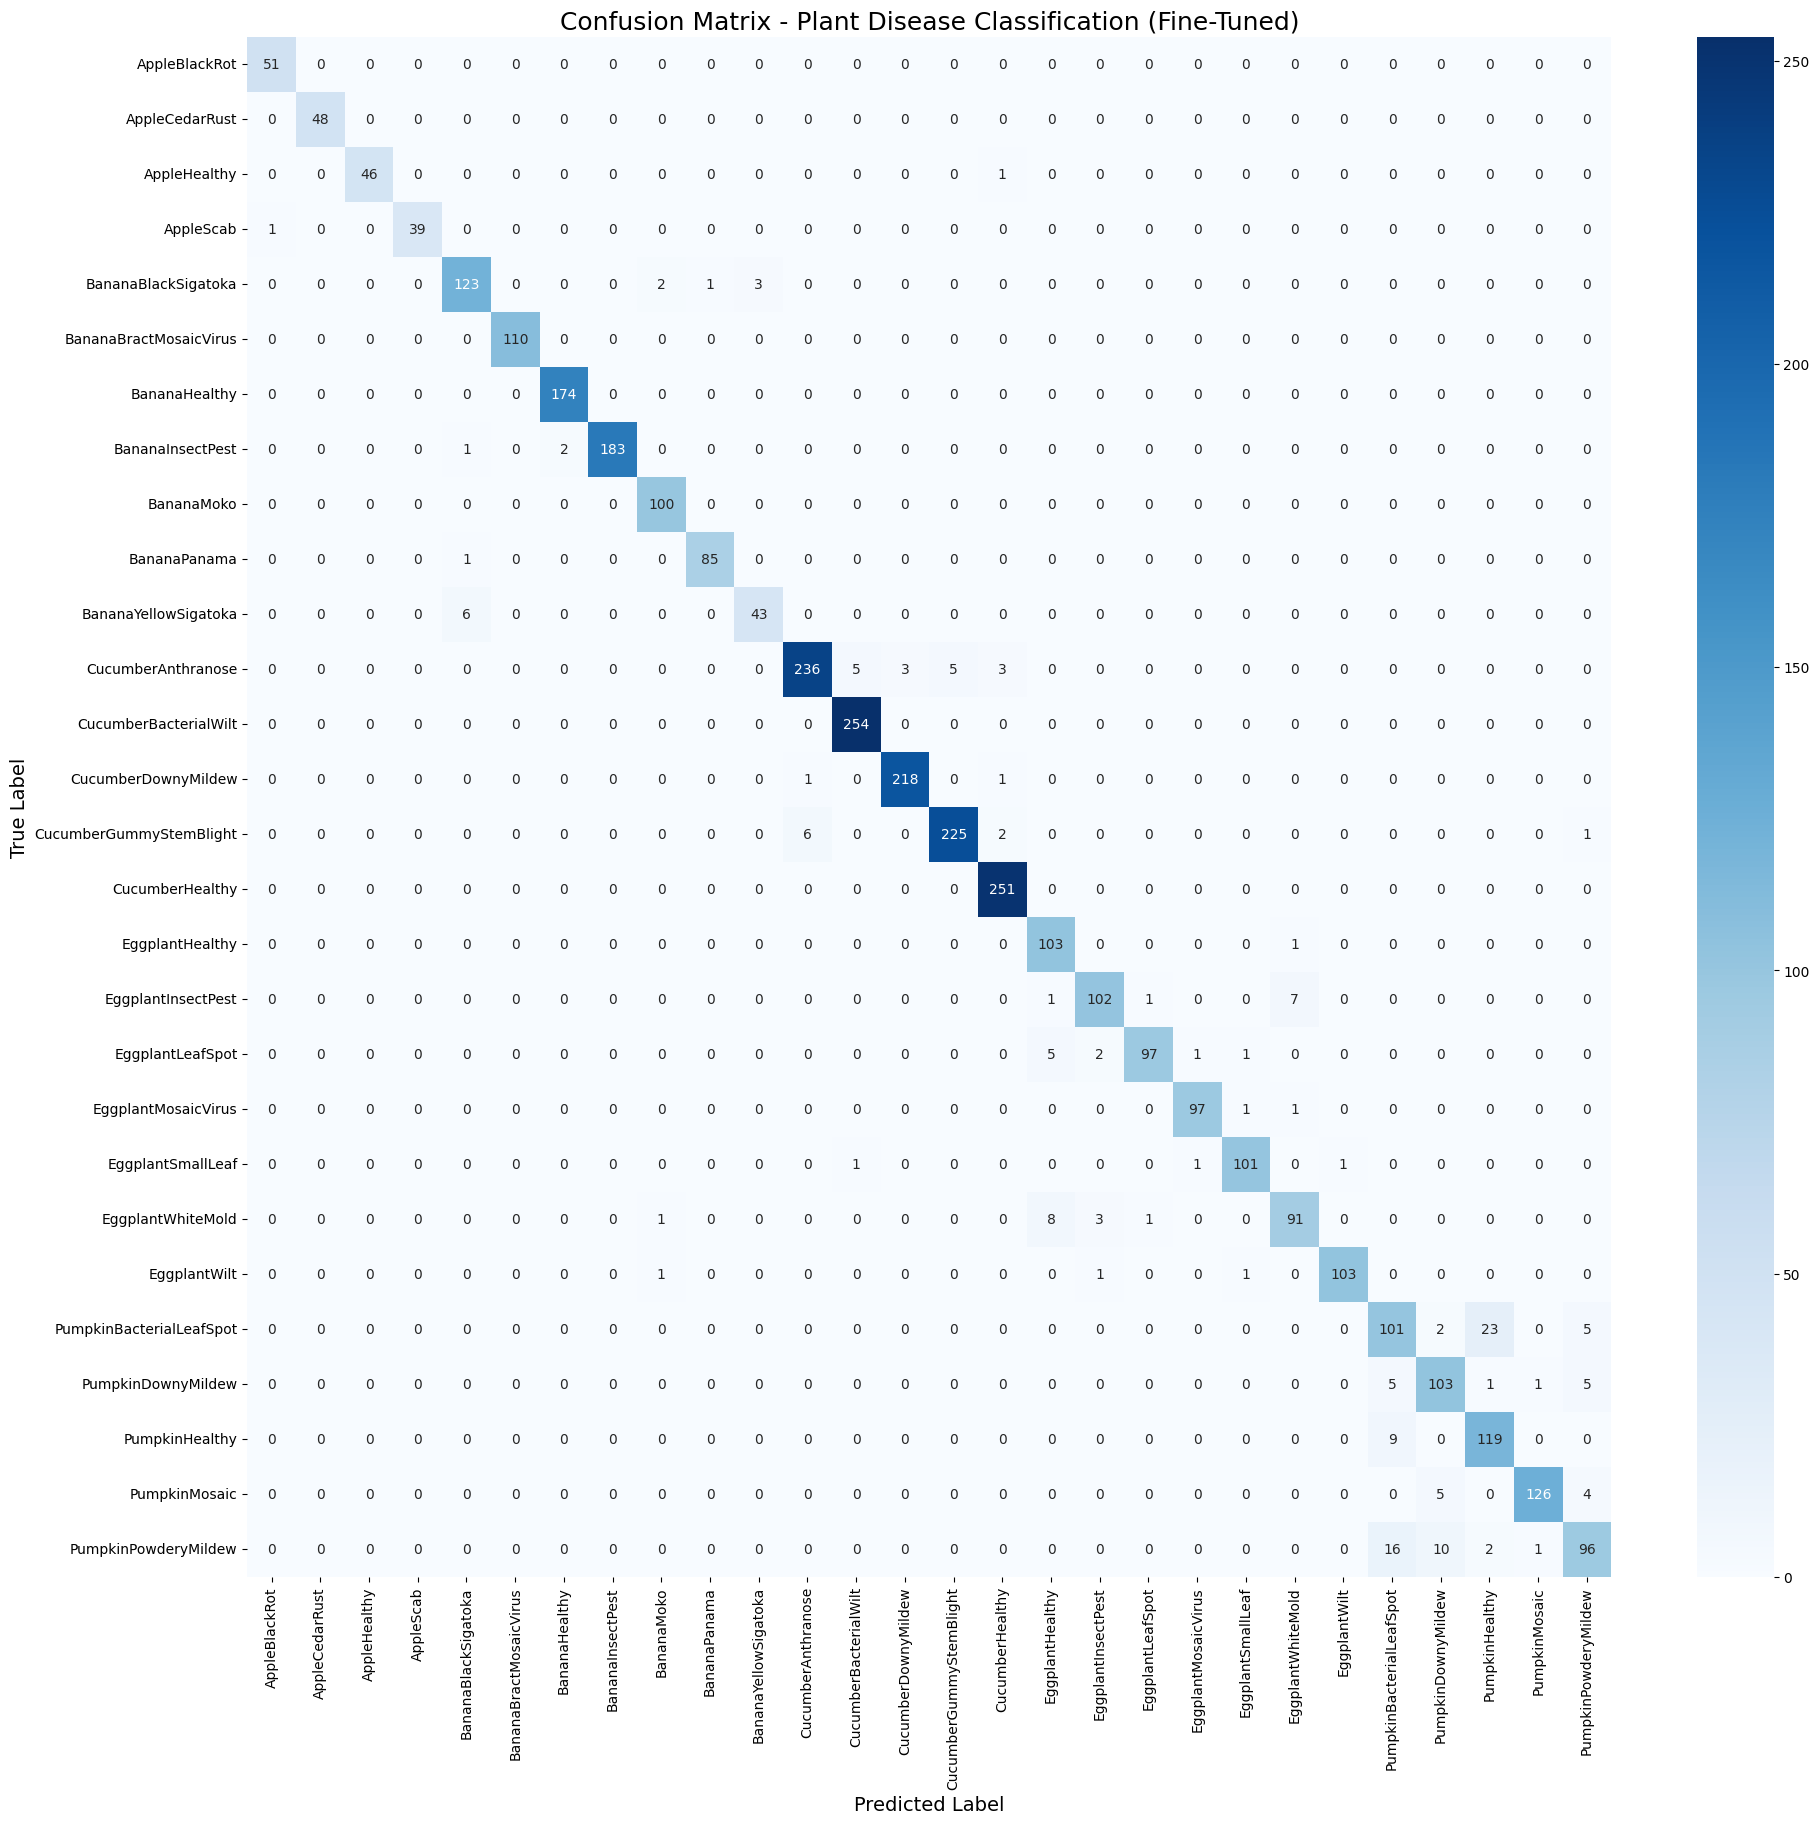


Triggering download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Detailed Classification Report ---
                          precision    recall  f1-score   support

           AppleBlackRot       0.98      1.00      0.99        51
          AppleCedarRust       1.00      1.00      1.00        48
            AppleHealthy       1.00      0.98      0.99        47
               AppleScab       1.00      0.97      0.99        40
     BananaBlackSigatoka       0.94      0.95      0.95       129
  BananaBractMosaicVirus       1.00      1.00      1.00       110
           BananaHealthy       0.99      1.00      0.99       174
        BananaInsectPest       1.00      0.98      0.99       186
              BananaMoko       0.96      1.00      0.98       100
            BananaPanama       0.99      0.99      0.99        86
    BananaYellowSigatoka       0.93      0.88      0.91        49
      CucumberAnthranose       0.97      0.94      0.95       252
   CucumberBacterialWilt       0.98      1.00      0.99       254
     CucumberDownyMildew       0.99

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files  # <-- Added Colab's download tool

print("Generating predictions on the validation set... (this takes a few seconds)")

y_true = []
y_pred_probs = []

# Loop through the validation dataset to get true labels and model predictions
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the Matrix
plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix - Plant Disease Classification (Fine-Tuned)', fontsize=18)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# --- SAVE AND DOWNLOAD THE IMAGE ---
file_name = 'confusion_matrix.png'
plt.savefig(file_name, bbox_inches='tight', dpi=300) # dpi=300 makes it high-resolution
plt.show()

print("\nTriggering download to your computer...")
files.download(file_name)

# Print a text-based report with Precision, Recall, and F1-Score
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))